In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import os
from pathlib import Path
from scipy.interpolate import interp1d as interp1d
import scipy.integrate as intg
import scipy

In [3]:
filename_DD = 'IDM_CTA_5.PhaseSpace_XENON1T_DD_all'
table_DD = open(filename_DD,'r')
Columns_DD = table_DD.readline().split()

data_DD = np.genfromtxt(filename_DD,dtype=float, comments='#')[1:,:]
table_DD.close()
values_DD = pd.DataFrame(data_DD,columns=Columns_DD)
values_DD

,Lambda345,MDM,IP,IN,DP,DN,pDD
0,0.0100,300.00,3.893500e-11,3.971200e-11,0.0,0.0,0.5
1,0.0100,306.00,3.742700e-11,3.817500e-11,0.0,0.0,0.5
2,0.0100,312.12,3.597800e-11,3.669700e-11,0.0,0.0,0.5
3,0.0100,318.36,3.458500e-11,3.527600e-11,0.0,0.0,0.5
4,0.0100,324.73,3.324600e-11,3.391000e-11,0.0,0.0,0.5
...,...,...,...,...,...,...,...
50789,6.1049,27413.00,1.748600e-09,1.783500e-09,0.0,0.0,0.5
50790,6.1049,27962.00,1.680700e-09,1.714300e-09,0.0,0.0,0.5
50791,6.1049,28521.00,1.615500e-09,1.647700e-09,0.0,0.0,0.5
50792,6.1049,29091.00,1.552700e-09,1.583700e-09,0.0,0.0,0.5


# Selecting LZ data

In [33]:
#data_DD = 'CDD_XENONnT'
data_DD = 'CDD_LZ'
lines = []
with open(data_DD) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data_lz = np.genfromtxt (lines, names = True ,dtype = None)

data_lz = pd.DataFrame(data_lz)
data_lz

sigmaDD_data = interp1d(data_lz['MDM'],data_lz['IN'])



In [34]:
data_lz

,MDM,IN
0,142.470678,4.147690e-47
1,153.962031,4.368492e-47
2,169.558042,4.675894e-47
3,191.383619,5.369478e-47
4,209.577443,6.004633e-47
5,226.053387,6.777124e-47
6,256.441604,7.552629e-47
7,277.300411,8.056188e-47
8,299.100400,8.573535e-47
9,334.422163,9.576654e-47


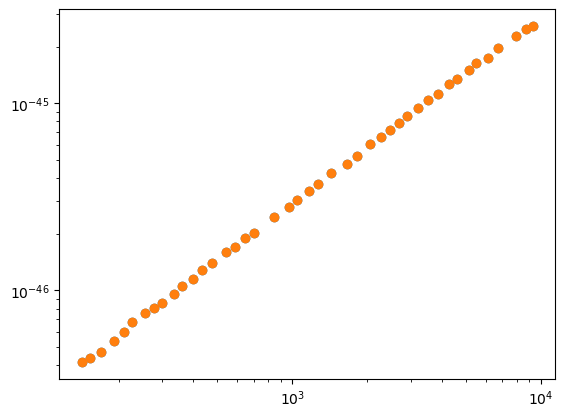

In [42]:
plt.scatter(data_lz['MDM'],sigmaDD_data(data_lz['MDM']))
plt.scatter(data_lz['MDM'],data_lz['IN'])
plt.xscale('log')
plt.yscale('log')

In [36]:
n = len(data_lz['MDM'])
data_lz['MDM']

0      142.470678
1      153.962031
2      169.558042
3      191.383619
4      209.577443
5      226.053387
6      256.441604
7      277.300411
8      299.100400
9      334.422163
10     361.395877
11     397.252184
12     431.737151
13     476.972807
14     539.728731
15     586.581909
16     644.780307
17     699.869581
18     846.702988
19     966.601428
20    1042.590857
21    1165.713887
22    1269.307248
23    1432.692964
24    1666.809963
25    1816.079119
26    2064.115017
27    2268.908559
28    2476.779433
29    2695.182855
30    2907.064818
31    3201.544017
32    3508.109497
33    3841.606843
34    4270.964761
35    4603.822603
36    5147.503359
37    5510.315563
38    6141.650404
39    6733.992718
40    7984.031141
41    8710.010411
42    9288.705251
Name: MDM, dtype: float64

In [46]:
def sigmaDD(m):
    if (m < data_lz['MDM'][n-40]):
        return sigmaDD_data(m)
    else:
        a = (data_lz['IN'][n-1] - data_lz['IN'][n-40])/(data_lz['MDM'][n-1] - data_lz['MDM'][n-40])
        return (m - data_lz['MDM'][n-40])*a + data_lz['IN'][n-40]
    #a = (data_xenon['IN'][n-1] - data_xenon['IN'][n-10])/(data_xenon['MDM'][n-1] - data_xenon['MDM'][n-10])
    #return (m - data_xenon['MDM'][n-1])*a + data_xenon['IN'][n-1]
sigmaDD = np.vectorize(sigmaDD)

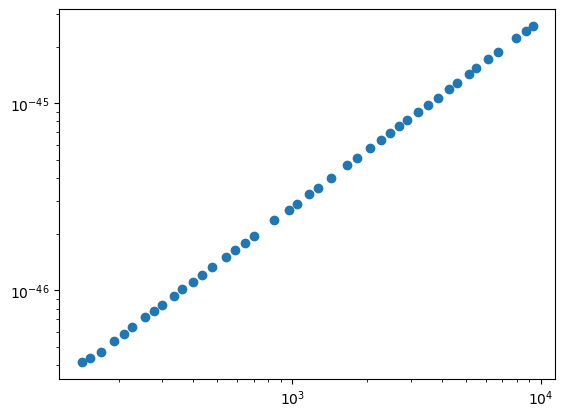

In [47]:
#plt.scatter(data_lz['MDM'],sigmaDD_data(data_lz['MDM']))
plt.scatter(data_lz['MDM'],sigmaDD(data_lz['MDM']))

plt.xscale('log')
plt.yscale('log')

In [48]:
m_range = np.geomspace(300,1e4,100)
sigmaDD_range = sigmaDD(m_range)

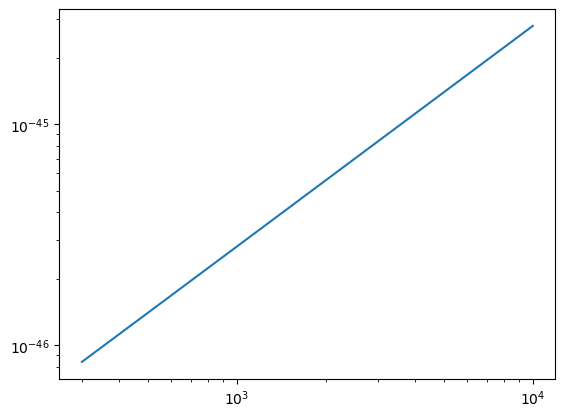

In [49]:
plt.plot(m_range,sigmaDD_range)
plt.xscale('log')
plt.yscale('log')

In [60]:
sigmaDD(1000)

array(2.79410487e-46)

In [56]:
lamb_DD = sorted(set(np.array(values_DD['Lambda345'])))
M_DD = sorted(set(np.array(values_DD['MDM'])))
CDD = []

for m in M_DD:
    sigma_lz = sigmaDD(m)*1e36# converting cm2 to pb
    condition = values_DD[((values_DD['IN']/sigma_lz - 1 <= 1e-2) & (values_DD['IN']/sigma_lz - 1 >= -1e-2) & (values_DD['MDM']/m - 1 <= 5e-2) & (values_DD['MDM']/m - 1 >= -5e-2) )]
    #l = np.mean(values_DD[((values_DD['IN']/sigma_xenon - 1 <= 1e-2) & (values_DD['IN']/sigma_xenon - 1 >= -1e-2))]['Lambda345'])
    l = np.mean(condition['Lambda345'])
    CDD.append(l)
CDD = np.array(CDD)    

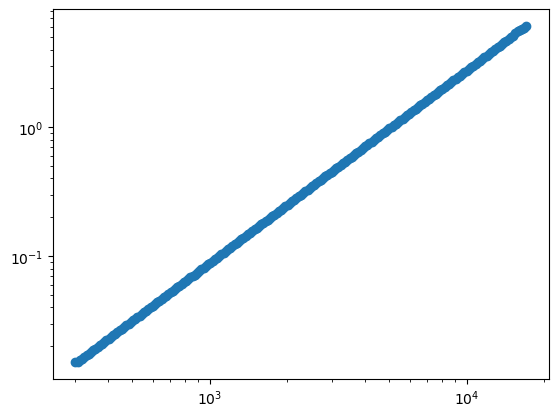

In [57]:
plt.scatter(M_DD,CDD)
plt.xscale('log')
plt.yscale('log')
#plt.xlim(1e2,3e4)
#plt.ylim(1e-2,1e1)

In [61]:
# Saving the Correct DD curves:
# It changes the files, run only if necessary!!!!!!!!

tableCDD = open('CDD_all_LZ','w')
tableCDD.write("Lambda345 MDM\n")

for i in range(len(M_DD)):
    #tableCDD.write(str(CDD['Lambda345'][line])+' '+str(CDD['MDM'][line])+' '+str(CDD['pDD'][line])+'\n')
    tableCDD.write(str(CDD[i])+' '+str(M_DD[i])+'\n')

tableCDD.close()